In [1]:
import torch

def collocation_points(*args):
    grids = torch.meshgrid(*args, indexing='ij')
    coord = torch.stack(grids, dim=len(args)).reshape(-1, len(args))
    return coord

In [2]:
nt = 3
nx = 3
t = torch.linspace(0, 1, nt)
x = torch.linspace(-1, 1, nx)
cdata = collocation_points(t, x)

print(f'{cdata.shape}\n{cdata}')

torch.Size([9, 2])
tensor([[ 0.0000, -1.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  1.0000],
        [ 0.5000, -1.0000],
        [ 0.5000,  0.0000],
        [ 0.5000,  1.0000],
        [ 1.0000, -1.0000],
        [ 1.0000,  0.0000],
        [ 1.0000,  1.0000]])


In [3]:
ny = 3
y = torch.linspace(-1, 1, ny)
cdata = collocation_points(t, y, x)
print(f'{cdata.shape}\n{cdata}')

torch.Size([27, 3])
tensor([[ 0.0000, -1.0000, -1.0000],
        [ 0.0000, -1.0000,  0.0000],
        [ 0.0000, -1.0000,  1.0000],
        [ 0.0000,  0.0000, -1.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0000],
        [ 0.0000,  1.0000, -1.0000],
        [ 0.0000,  1.0000,  0.0000],
        [ 0.0000,  1.0000,  1.0000],
        [ 0.5000, -1.0000, -1.0000],
        [ 0.5000, -1.0000,  0.0000],
        [ 0.5000, -1.0000,  1.0000],
        [ 0.5000,  0.0000, -1.0000],
        [ 0.5000,  0.0000,  0.0000],
        [ 0.5000,  0.0000,  1.0000],
        [ 0.5000,  1.0000, -1.0000],
        [ 0.5000,  1.0000,  0.0000],
        [ 0.5000,  1.0000,  1.0000],
        [ 1.0000, -1.0000, -1.0000],
        [ 1.0000, -1.0000,  0.0000],
        [ 1.0000, -1.0000,  1.0000],
        [ 1.0000,  0.0000, -1.0000],
        [ 1.0000,  0.0000,  0.0000],
        [ 1.0000,  0.0000,  1.0000],
        [ 1.0000,  1.0000, -1.0000],
        [ 1.0000,  1.0000,  0.0000],
        [ 1.0000, 

### Initial Condition

In [4]:
u0 = torch.sin(x)
inidata = collocation_points(t[0], x)
print(f'{inidata.shape}\n{inidata}')

torch.Size([3, 2])
tensor([[ 0., -1.],
        [ 0.,  0.],
        [ 0.,  1.]])


In [5]:
u0

tensor([-0.8415,  0.0000,  0.8415])

### Boundary Condition

In [6]:
xbg = torch.FloatTensor([x[0], x[-1]])
bgdata = collocation_points(t, xbg)
print(f'{bgdata.shape}\n{bgdata}')

torch.Size([6, 2])
tensor([[ 0.0000, -1.0000],
        [ 0.0000,  1.0000],
        [ 0.5000, -1.0000],
        [ 0.5000,  1.0000],
        [ 1.0000, -1.0000],
        [ 1.0000,  1.0000]])


In [7]:
class TensorData(torch.utils.data.Dataset):
    def __init__(self, cdata):
        self.cdata = cdata
        self.len = len(cdata)

    def __getitem__(self, index):
        return self.cdata[index]

    def __len__(self):
        return self.len

batch_size = 8
train_loader = torch.utils.data.DataLoader(TensorData(cdata), batch_size=batch_size, shuffle=True)

In [8]:
dataiter = iter(train_loader)
batch_cdata = next(dataiter)
print(batch_cdata)

tensor([[ 1.0000,  0.0000,  1.0000],
        [ 0.5000,  0.0000,  0.0000],
        [ 1.0000,  1.0000,  0.0000],
        [ 1.0000,  0.0000,  0.0000],
        [ 1.0000,  1.0000, -1.0000],
        [ 0.5000, -1.0000, -1.0000],
        [ 1.0000, -1.0000, -1.0000],
        [ 0.0000,  1.0000, -1.0000]])


### Basic Neural Network Models

In [9]:
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm

In [10]:
class LinearBlock(nn.Module):
    def __init__(self, in_nodes, out_nodes):
        super(LinearBlock, self).__init__()
        self.layer = weight_norm(nn.Linear(in_nodes, out_nodes), dim=0)

    def forward(self, x):
        x = self.layer(x)
        x = torch.tanh(x)
        return x

class MLP(nn.Module):
    def __init__(self, layer_list):
        super(MLP, self).__init__()
        self.input_layer = weight_norm(nn.Linear(layer_list[0], layer_list[1]), dim=0)
        self.hidden_layers = self._make_layer(layer_list[1:-1])
        self.output_layer = nn.Linear(layer_list[-2], layer_list[-1])

    def _make_layer(self, layer_list):
        layers = []
        for i in range(len(layer_list) - 1):
            block = LinearBlock(layer_list[i], layer_list[i + 1])
            layers.append(block)
        return nn.Sequential(*layers)

    def forward(self, x):
        x = torch.tanh(self.input_layer(x))
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x

def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)

def pinn(layer_list):
    model = MLP(layer_list)
    model.apply(weights_init)
    return model

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("operation mode: ", device)

num_hidden = 4
num_nodes = 128

layer_list = [2] + num_hidden * [num_nodes] + [1]
model = pinn(layer_list).to(device)

operation mode:  cuda:0


In [12]:
model

MLP(
  (input_layer): ParametrizedLinear(
    in_features=2, out_features=128, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (hidden_layers): Sequential(
    (0): LinearBlock(
      (layer): ParametrizedLinear(
        in_features=128, out_features=128, bias=True
        (parametrizations): ModuleDict(
          (weight): ParametrizationList(
            (0): _WeightNorm()
          )
        )
      )
    )
    (1): LinearBlock(
      (layer): ParametrizedLinear(
        in_features=128, out_features=128, bias=True
        (parametrizations): ModuleDict(
          (weight): ParametrizationList(
            (0): _WeightNorm()
          )
        )
      )
    )
    (2): LinearBlock(
      (layer): ParametrizedLinear(
        in_features=128, out_features=128, bias=True
        (parametrizations): ModuleDict(
          (weight): ParametrizationList(
            (0): _WeightNorm()
          )
        )
  

In [13]:
x = torch.normal(0, 1, (3, 2)).to(device)

### Learning

In [14]:
import utils

def f(cdata):
    return torch.sin(5*cdata[:, 0]) * torch.cos(5*cdata[:, 1]) / 20

nx = 20
ny = 20

x = torch.linspace(-1, 1, nx)
y = torch.linspace(-1, 1, ny)
cdata = utils.collocation_points(x, y).to(device)
z = f(cdata)
z = z.reshape(-1, 1)
print(cdata.shape, z.shape)

torch.Size([400, 2]) torch.Size([400, 1])


In [15]:
criterion = nn.MSELoss()
lr = 5e-3
num_epochs = 5000
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [16]:
loss_graph = []

for _ in range(num_epochs):
    optimizer.zero_grad()
    z_pred = model(cdata)
    loss = criterion(z_pred, z)
    loss.backward()
    optimizer.step()

    loss_graph.append(loss.item())

print(f'mse : {loss_graph[-1]}')
torch.save(model.state_dict(), './sierra.pt')

mse : 7.816201105015352e-05


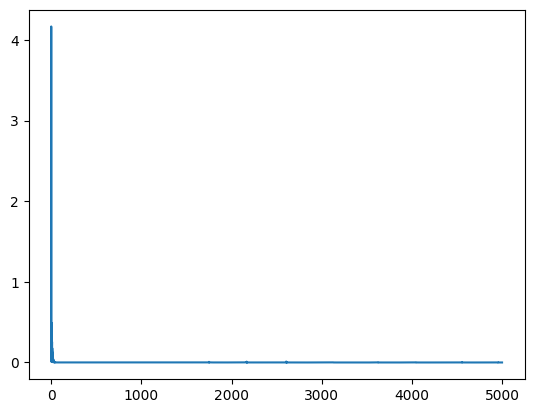

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.plot(loss_graph)
plt.show()

In [ ]:
model.load_state_dict(torch.load('./param/sierra.pt', map_location=device))

nx = 50
ny = 50
x_t = torch.linspace(-1, 1, nx)
y_t = torch.linspace(-1, 1, ny)
cdata_test = utils.collocation_points(x_t, y_t).to(device)
z_test = f(cdata_test)
with torch.no_grad():
    z_pred = model(cdata_test).squeeze()


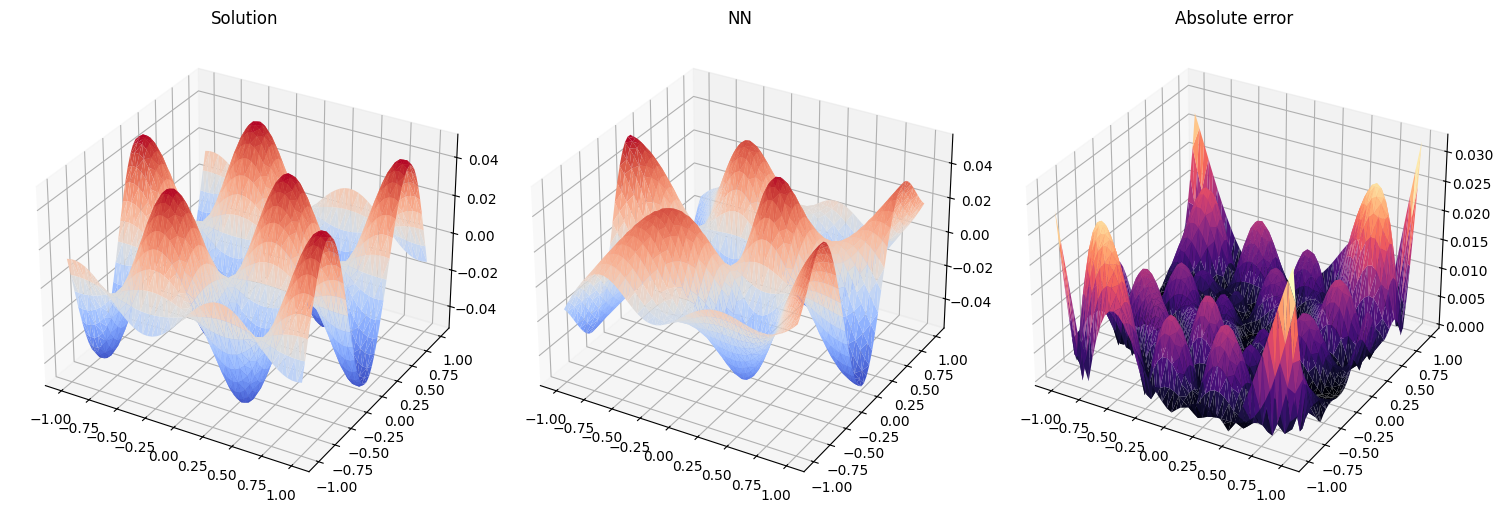

In [21]:
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(cdata_test.cpu().numpy()[:,0], cdata_test.cpu().numpy()[:,1], z_test.cpu().numpy(), cmap='coolwarm')
ax1.set_title('Solution')
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(cdata_test.cpu().numpy()[:,0], cdata_test.cpu().numpy()[:,1], z_pred.cpu().numpy(), cmap='coolwarm')
ax2.set_title('NN')
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_trisurf(cdata_test.cpu().numpy()[:,0], cdata_test.cpu().numpy()[:,1], abs(z_test-z_pred).cpu().numpy(), cmap='magma')
ax3.set_title('Absolute error')
plt.tight_layout()
plt.show()